{'normal': [neutrophil     0.236448
epithelial    42.111449
lymphocyte    18.438970
plasma         6.783776
eosinophil     0.421451
connective    11.591877
dtype: float64, neutrophil     0.199441
epithelial    80.884102
lymphocyte    31.486036
plasma        16.456489
eosinophil     1.147725
connective    16.029761
dtype: float64], 'coeliac': [neutrophil     0.578321
epithelial    54.803016
lymphocyte    24.893400
plasma        12.012713
eosinophil     0.414775
connective    18.760443
dtype: float64, neutrophil     0.084479
epithelial    75.046695
lymphocyte    20.988288
plasma        13.625190
eosinophil     0.495732
connective    17.656490
dtype: float64]}


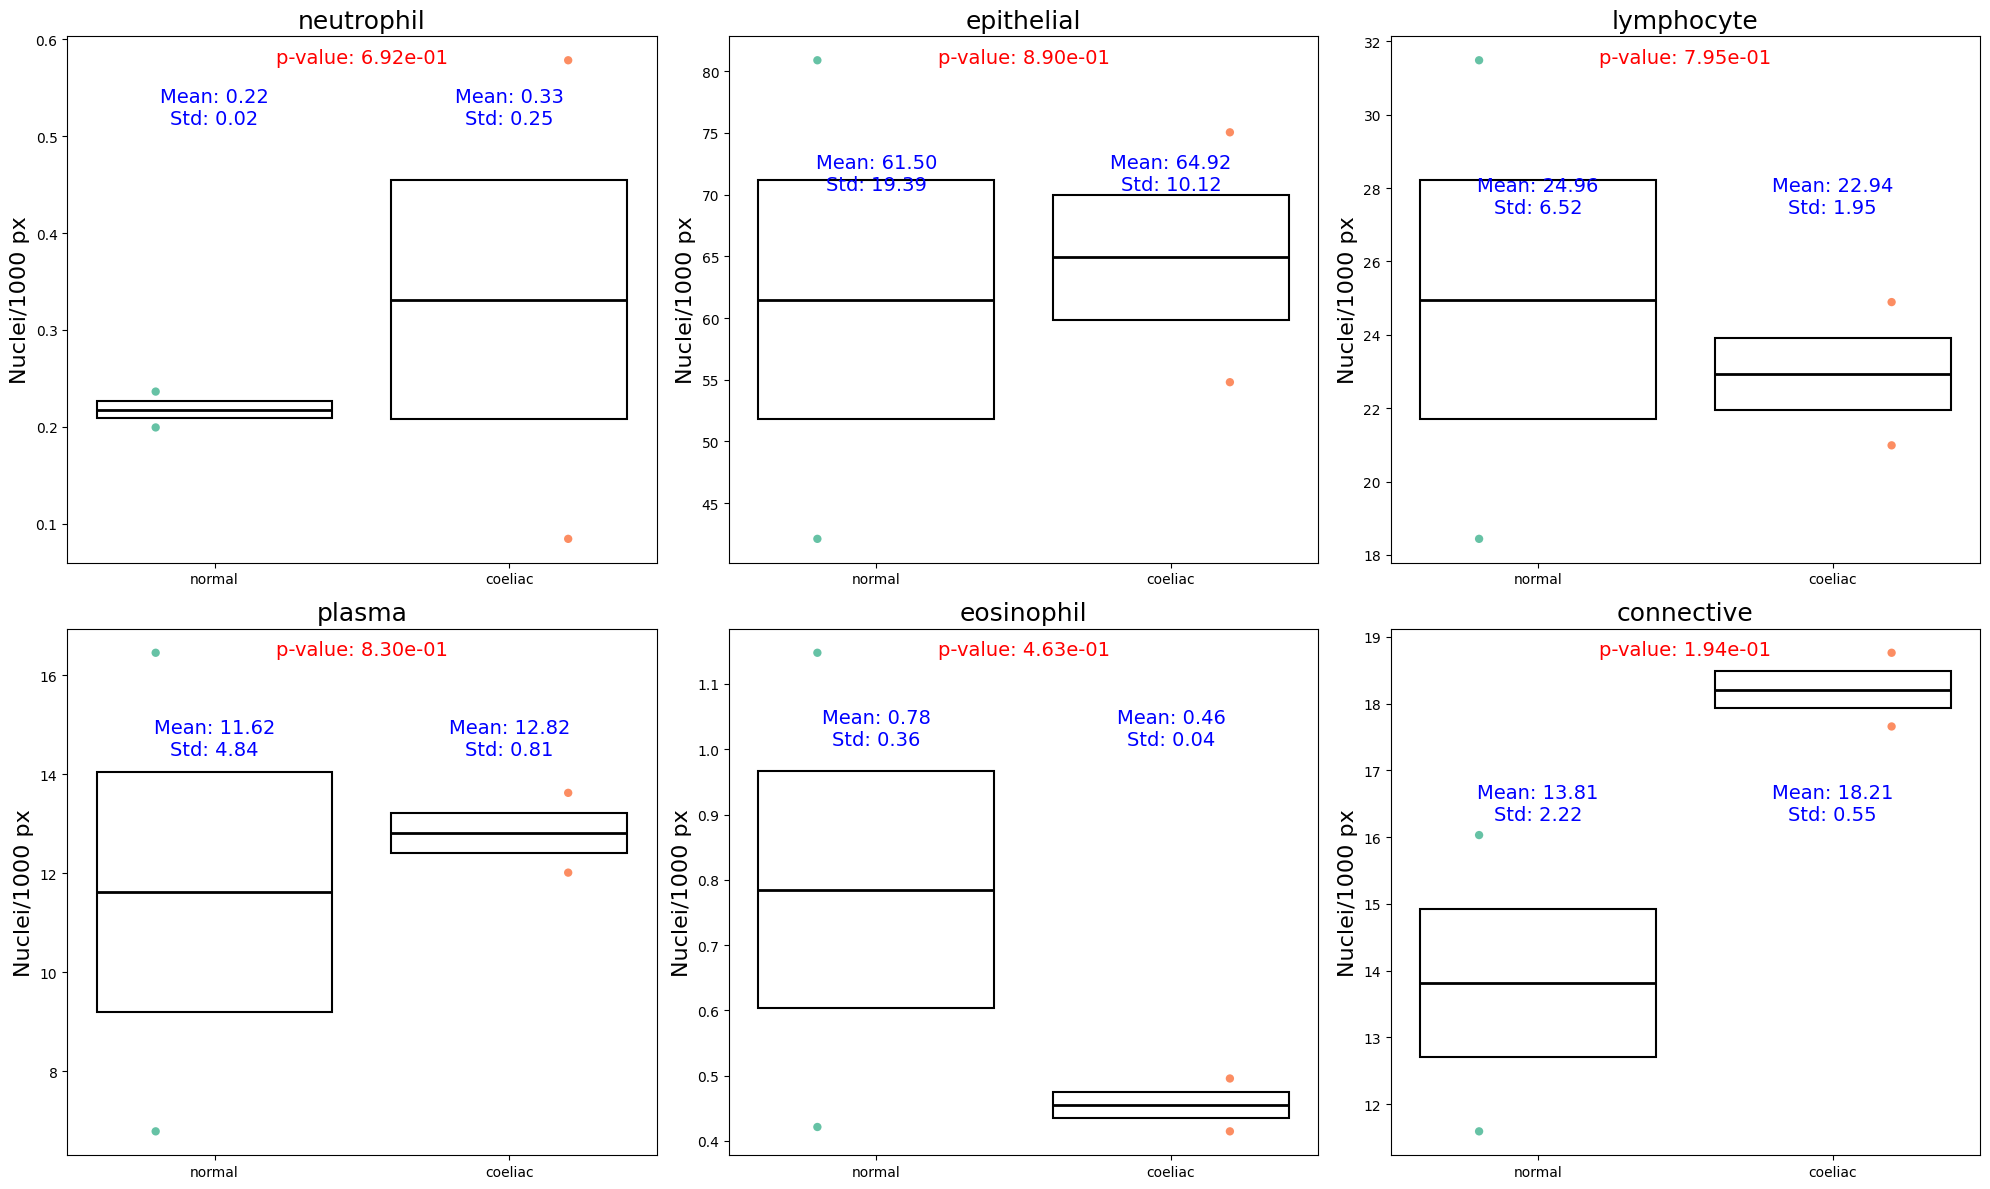

In [49]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy.stats import ttest_ind
import json
import glob
import os

DIRECTORY = '/rds/user/mf774/hpc-work/part_II_project/lizard/hover_net-conic/toy_data_256_256_20x_inference/'
nuclei_densities = {
    "normal": [],
    "coeliac": []
}

os.chdir('/home/mf774/rds/hpc-work/part_II_project/lizard/hover_net-conic/notebooks/in-house-dummy-inference/statistical-analysis/')

def get_area_from_metadata(file_path, i):
    metadata_path = f'{file_path}/{i}/metadata.json'
    with open(metadata_path, "r") as f:
        metadata = json.load(f)
    area = metadata["tissue_area_og_mask"]
    return area


def get_total_nuclei(file_path, i):
    csv_path = f'{file_path}/{i}/valid_pred_cell.csv'
    df = pd.read_csv(csv_path)
    total_nuclei = df.sum(axis=0)
    return(total_nuclei)


def get_nuclei_density(total_nuclei, area):
    return total_nuclei/area*1000

if __name__ == '__main__':
    disease_classes = os.listdir(DIRECTORY)
    for disease in disease_classes:
        disease_case_nums = os.listdir(f'{DIRECTORY}/{disease}/')
        for case in disease_case_nums:
            case_area = get_area_from_metadata(f'{DIRECTORY}/{disease}', case)
            case_total_nuclei = get_total_nuclei(f'{DIRECTORY}/{disease}', case)
            case_nuclei_density = get_nuclei_density(case_total_nuclei, case_area)
            nuclei_densities[disease].append(case_nuclei_density)

print(nuclei_densities)

df_list = []
for condition, samples in nuclei_densities.items():
    for sample in samples:
        df_sample = sample.to_frame().reset_index()
        df_sample.columns = ['Cell Type', 'Count']
        df_sample['Condition'] = condition
        df_list.append(df_sample)

df = pd.concat(df_list, ignore_index=True)

# Get unique cell types
cell_types = df['Cell Type'].unique()

# Create figure with 2 rows and 3 columns
fig, axes = plt.subplots(2, 3, figsize=(20, 12))
axes = axes.flatten()

# Iterate over each cell type and plot
for i, cell_type in enumerate(cell_types):
    ax = axes[i]
    
    # Swarmplot
    sns.swarmplot(ax=ax, x='Condition', y='Count', data=df[df['Cell Type'] == cell_type], 
                  hue='Condition', palette="Set2", size=6, zorder=1, dodge=True)
    
    # Boxplot
    sns.boxplot(ax=ax, x='Condition', y='Count', data=df[df['Cell Type'] == cell_type], 
                showmeans=False, meanline=False, showfliers=False, 
                whiskerprops={'visible': False}, capprops={'visible': False}, 
                medianprops={'color': 'black', 'linewidth': 2, 'zorder': 2}, 
                boxprops={'facecolor': 'none', 'edgecolor': 'black', 'linewidth': 1.5, 'zorder': 2})
    
    # Set title and labels
    ax.set_title(cell_type, fontsize=18)
    ax.set_xlabel('')
    ax.set_ylabel('Nuclei/1000 px', fontsize=16)
    
    # T-test for p-value
    group1 = df[(df['Cell Type'] == cell_type) & (df['Condition'] == 'normal')]['Count']
    group2 = df[(df['Cell Type'] == cell_type) & (df['Condition'] == 'coeliac')]['Count']
    _, p_value = ttest_ind(group1, group2)
    
    # Display p-value on the plot
    ax.annotate(f'p-value: {p_value:.2e}', xy=(0.5, 0.95), xycoords='axes fraction',
                ha='center', fontsize=14, color='red')

    # Display mean and std for each group
    for j, condition in enumerate(['normal', 'coeliac']):
        condition_data = df[(df['Cell Type'] == cell_type) & (df['Condition'] == condition)]['Count']
        mean = np.mean(condition_data)
        std = np.std(condition_data)

        # Position text near the top of the plot
        ax.text(j, ax.get_ylim()[1] * 0.85, f'Mean: {mean:.2f}\nStd: {std:.2f}', 
                ha='center', fontsize=14, color='blue')

# Adjust layout and show plot
plt.tight_layout()
plt.savefig("normal_vs_coeliac_nulcei_densities.png")
plt.show()